[<< stats home](./home.md)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import scipy.stats as stats
from helper_functions import print_image

test_data_dir = '../test_data'

# stats for data science
cursory notes following the lectures

## descriptive v.s. inferential stats
- descriptive stats - describe and summarize data
- inferential stats - make inferences about a population based on a sample

## fundamental terms in distributions
- probability mass function is used for discrete data
- probability density function is used for continuous data

# binomial dist
binomial dist is a discrete dist that models the number of successes in a fixed number of trials 
- e.g. probability of $X$ heads in 10 coin flips
- e.g. probabilities of 1, 5, 10 or 20 defective parts in a batch of 100

$ P(X = x) = \binom{n}{x} p^x(1-p)^{n-x} $

$ \binom{n}{x} = \frac{n!}{x!(n-x)!} $

## bernoulli distribution
probability of success v.s. failure for a single trial

#### example case

80% of all the visitors to lavista museum end up bying souvenirs from the shop at the museum. on the coming sunday, if a random sample of 10 visitors is selected:
1. find the probability that every visitor will end up buying from the shop
2. frind the prob. that a max of 7 visitors iwll buy souvenirs from the shop

do we satisfy the following assumptions?
- there are only 2 possible outcomes (success or failure) for each trial - a visitor will buy souvenirs from the shop or not (yes or no)
- number of trials (n) is fixed - there are 10 visitors in the sample
- each trial is independent of the other trials - it is reasonable to assume that the buying activity of visitors are independent
- the probability of success (p) is the same for each trial - the probability of success for each visitor is 0.8

k: [ 0  1  2  3  4  5  6  7  8  9 10]


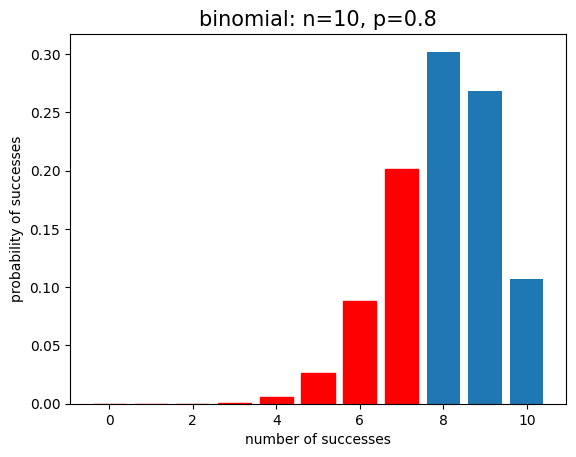

In [3]:
n = 10
p = 0.8
k = np.arange(0, 11) # get list of possible number of visitors from 0 to 10
print('k:', k)

# use probability mass function (pmf) to calculate the probability of getting k successes
#   -  pmf is used for discrete distributions to get the probability of a specific value.
#   -  for continuous distributions, use probability density function (pdf)
binomial = stats.binom.pmf(k=k, n=n, p=p)

# visualization
bar1 = plt.bar(k, binomial)
plt.title(f'binomial: n={n}, p={p}', fontsize = 15)
plt.xlabel('number of successes')
plt.ylabel('probability of successes')

# color bars for 0-7 successes (sum these to get cdf)
for i in range(0, 8):
    bar1[i].set_color('r')
plt.show()

In [ ]:
def percentile_string(num):
    return format(num * 100, '.2f') + '%'

answer1 = binomial[10]
# answer2 = binomial[:8].sum()
answer2 = stats.binom.cdf(k=7, n=n, p=p) # cumulative distribution function

print(f'Answer 1 - the probability that everyone buys something = {percentile_string(answer1)}')
print(f'Answer 2 - the probability that a max of 7 people will buy something = {percentile_string(answer2)}')

# Uniform Distribution

In [5]:
df_debugging = pd.read_csv(f'{test_data_dir}/debugging.csv')
df_debugging.head()

,Bug ID,Time Taken to fix the bug
0,12986,2.42
1,12987,2.03
2,12988,2.74
3,12989,3.21
4,12990,3.40


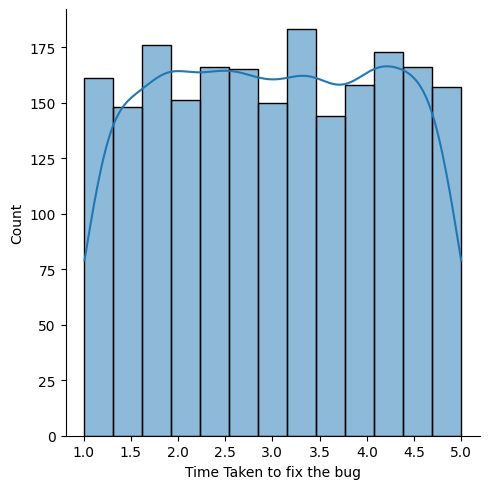

In [6]:
# here se see that the data is normally distributed between 1 & 5. these are the only numbers that we need in order to create a normal distribution. see examples below.
sns.displot(df_debugging['Time Taken to fix the bug'], kde=True)
plt.show()

In [7]:
x = np.linspace(1, 5, 50)
probs = stats.uniform.pdf(x, loc=1, scale=4)

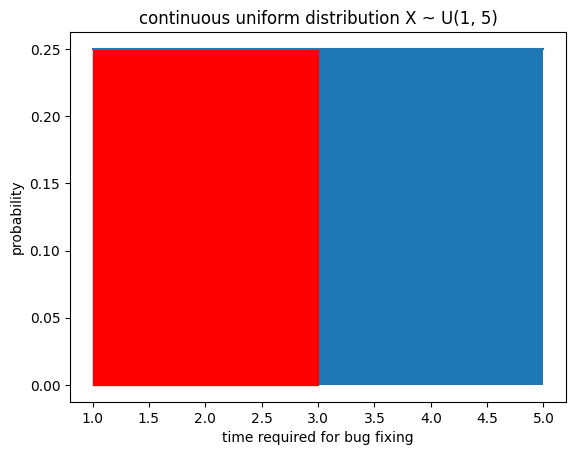

In [8]:
x1 = np.linspace(1, 3, 25)
plt.plot(x, probs)
plt.fill_between(x, probs)
plt.fill_between(x1, stats.uniform.pdf(x=x1, loc=1, scale=4), color='r')
plt.xlabel('time required for bug fixing')
plt.ylabel('probability')
plt.title('continuous uniform distribution X ~ U(1, 5)')
plt.show()

In [9]:
# a distribution of U(1, 5) starts at 1 and has a range of (5-1) = 4

# cdf = cumulative probablity distribution function
p_less_than_x = stats.uniform.cdf(3, loc=1, scale=4)

# ppf = percent point function
#     = the point at which the cumulative distribution function is equal to the given probability
x_given_p = stats.uniform.ppf(0.25, loc=1, scale=4)

# pdf = probability density function
#     = the probability that the variable takes on the value x
pdf = stats.uniform.pdf(3, loc=1, scale=4)

print('p_less_than_x (3): ', p_less_than_x)
print('x_given_p:         ', x_given_p)
print('pdf:               ', pdf)

p_less_than_x (3):  0.5
x_given_p:          2.0
pdf:                0.25


# Normal Distribution

In [10]:
def z_score(x, mean, std):
    # this is a normalized measure of how many standard deviations a value is from the mean
    return (x - mean) / std

def x_value(z, mean, std):
    # this is the reverse of z_score
    return z * std + mean

percentage_of_data_within_n_std = {
    1: 0.68, # 68% of the data is within 1 standard deviation
    2: 0.95, # 95% of the data is within 2 standard deviations
    3: 0.997 # 99.7% of the data is within 3 standard deviations
}

# z-score comparison example
#   -  which class is the student doing the best in?
df = pd.DataFrame()
df['class'] = ['physics', 'history', 'computer science']
df['mean'] = [47.5, 77, 33]
df['std'] = [12.3, 8.2, 7.3]
df['score'] = [56.88, 77.1, 35.55]
df['z'] = z_score(df['score'], df['mean'], df['std'])
df

,class,mean,std,score,z
0,physics,47.5,12.3,56.88,0.762602
1,history,77.0,8.2,77.10,0.012195
2,computer science,33.0,7.3,35.55,0.349315


In [11]:
from scipy.stats import norm
df_sat_score = pd.read_csv(f'{test_data_dir}/sat_score.csv')
print('mean: ', df_sat_score['score'].mean().round(2))
print('std:  ', df_sat_score['score'].std().round(2))
df_sat_score.head()

mean:  1007.46
std:   204.43


,student_id,score
0,1,1018
1,2,1218
2,3,611
3,4,723
4,5,541


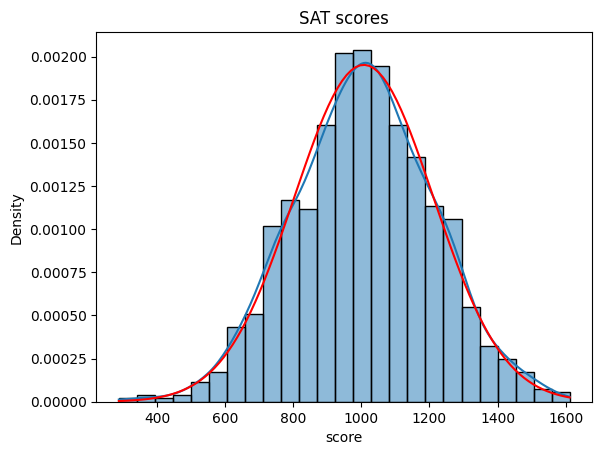

In [12]:
# calculate the pdf of SAT scores using stats.norm.pdf()
df_density = pd.DataFrame()
df_density['x'] = np.linspace(
    df_sat_score['score'].min() - 0.01, 
    df_sat_score['score'].max() + 0.01, 
    100
)
# for each x in X, get the probability of x given the mean and std of the SAT scores
df_density['pdf'] = stats.norm.pdf(
    df_density['x'], 
    df_sat_score['score'].mean(), 
    df_sat_score['score'].std()
)

# plot the density
# here we see that the data very closely follows a normal distribution
fig, ax = plt.subplots()
sns.histplot(df_sat_score['score'], kde=True, ax=ax, stat='density') # raw data in blue
ax.plot(df_density['x'], df_density['pdf'], color='red')             # normal distribution in red
plt.title('SAT scores')
plt.show()

mean:  1007.46
std:   204.43
p_less_than_x (800): 0.16


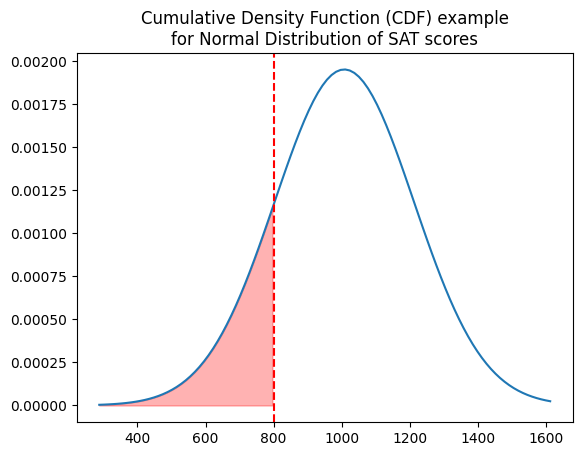

In [13]:
mean = df_sat_score['score'].mean()
std = df_sat_score['score'].std()
x = 800
p_less_than_n = stats.norm.cdf(x, mean, std)
print('mean: ', mean.round(2))
print('std:  ', std.round(2))
print(f'p_less_than_x ({x}): {p_less_than_n.round(2)}')

# plot to see
plt.plot(df_density['x'], df_density['pdf'])
plt.axvline(x=x, color='r', linestyle='--')
plt.fill_between(df_density['x'], df_density['pdf'], where=(df_density['x'] < x), color='r', alpha=0.3)
plt.title('Cumulative Density Function (CDF) example\nfor Normal Distribution of SAT scores')
plt.show()

x_given_p (0.95): 1343.71


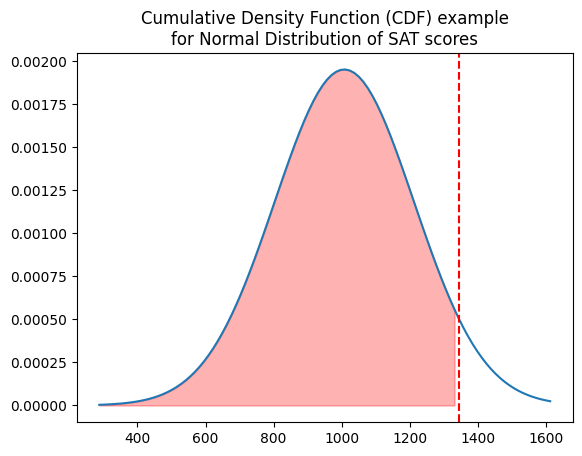

In [14]:
# ppf = estimated score given the percentile
# - note that ppf is the reverse of cdf
p = 0.95
x_given_p = stats.norm.ppf(p, mean, std)
print(f'x_given_p ({p}): {x_given_p.round(2)}')

# plot to see
plt.plot(df_density['x'], df_density['pdf'])
plt.axvline(x=x_given_p, color='r', linestyle='--')
plt.fill_between(df_density['x'], df_density['pdf'], where=(df_density['x'] < x_given_p), color='r', alpha=0.3)
plt.title('Cumulative Density Function (CDF) example\nfor Normal Distribution of SAT scores')
plt.show()


# Sampling Data and Inference Foundations

**sample_std** of sample_mean = **population_std** / sqrt(n)
- as n increases, the standard deviation of the sample mean decreases
- as n increases, the sample mean becomes more accurate
- as n increases, the sample mean becomes more normally distributed (even if the original data is not normally distributed)
    - this is because the sample mean is the sum of many random variables, and the central limit theorem states that 
    - the sum of many random variables is normally distributed, regardless of the distribution of the original random variables

# Central Limit Theorem

the sampling distribution of the sample means will approach normal distribution as the sample size gets bigger, no matter what the shape of the population distribution is.
- i.e. the averages of random samples are approximately normally distributed.

### assumptions:
- data must be randomly sampled
- sample valuse must be independent of each other
- sample size must be sufficiently large (n > 30)
- Samples should come from the same distribution

### we'll also notice some other behaviors:
- the mean of the sample means will be approximately equal to the population mean

- as the sample size gets bigger, the standard deviation of the sample means gets smaller
    - i.e. the sample means become more accurate and samples are more concentrated around the sample mean
    - i.e. the distribution becomes more normal and **narrower**
    
- the standard deviation of the sample means will be approximately equal to the population standard deviation divided by the square root of the sample size
<font size=5>

$$ \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}} $$
</font>



In [15]:
def sample_distributions(population):
    seeds = [3, 7, 9]
    sample_sizes = [5, 15, 30, 50, 100]
    n_samples = np.repeat(100, len(sample_sizes))
    sample_means = []
    for seed_index in range(0, len(seeds)):
        np.random.seed(seeds[seed_index])

        # create sampling distribution from the population
        sample_means.append([])
        for i in range(len(sample_sizes)):
            for _ in range(n_samples[i]):
                sample_means[seed_index].append([])
                sample_size = sample_sizes[i]
                sample = np.random.choice(population, size=sample_size)
                sample_means[seed_index][i].append(sample.mean())


    # plot the normal and sampling distributions
    num_rows = len(seeds)
    num_cols = len(sample_sizes) + 1
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(20, 15))
    for ri in range(num_rows):
        ax_normal = axs[ri][0]
        sns.histplot(population, kde=True, ax=ax_normal)
        ax_normal.set_title('Population Distribution')
        ax_normal.set_xlabel('value')
        ax_normal.set_ylabel('frequency')

        for i in range(num_cols - 1):
            ax = axs[ri][i + 1]
            sns.histplot(sample_means[ri][i], kde=True, ax=ax)

            ax.set_title(f'Sampling Distribution\n(sample size = {sample_sizes[i]})\n (random seed = {seeds[ri]})')
            ax.set_xlabel('mean value')
            ax.set_ylabel('frequency')

    # increase padding between rows
    plt.tight_layout(h_pad=3.0)

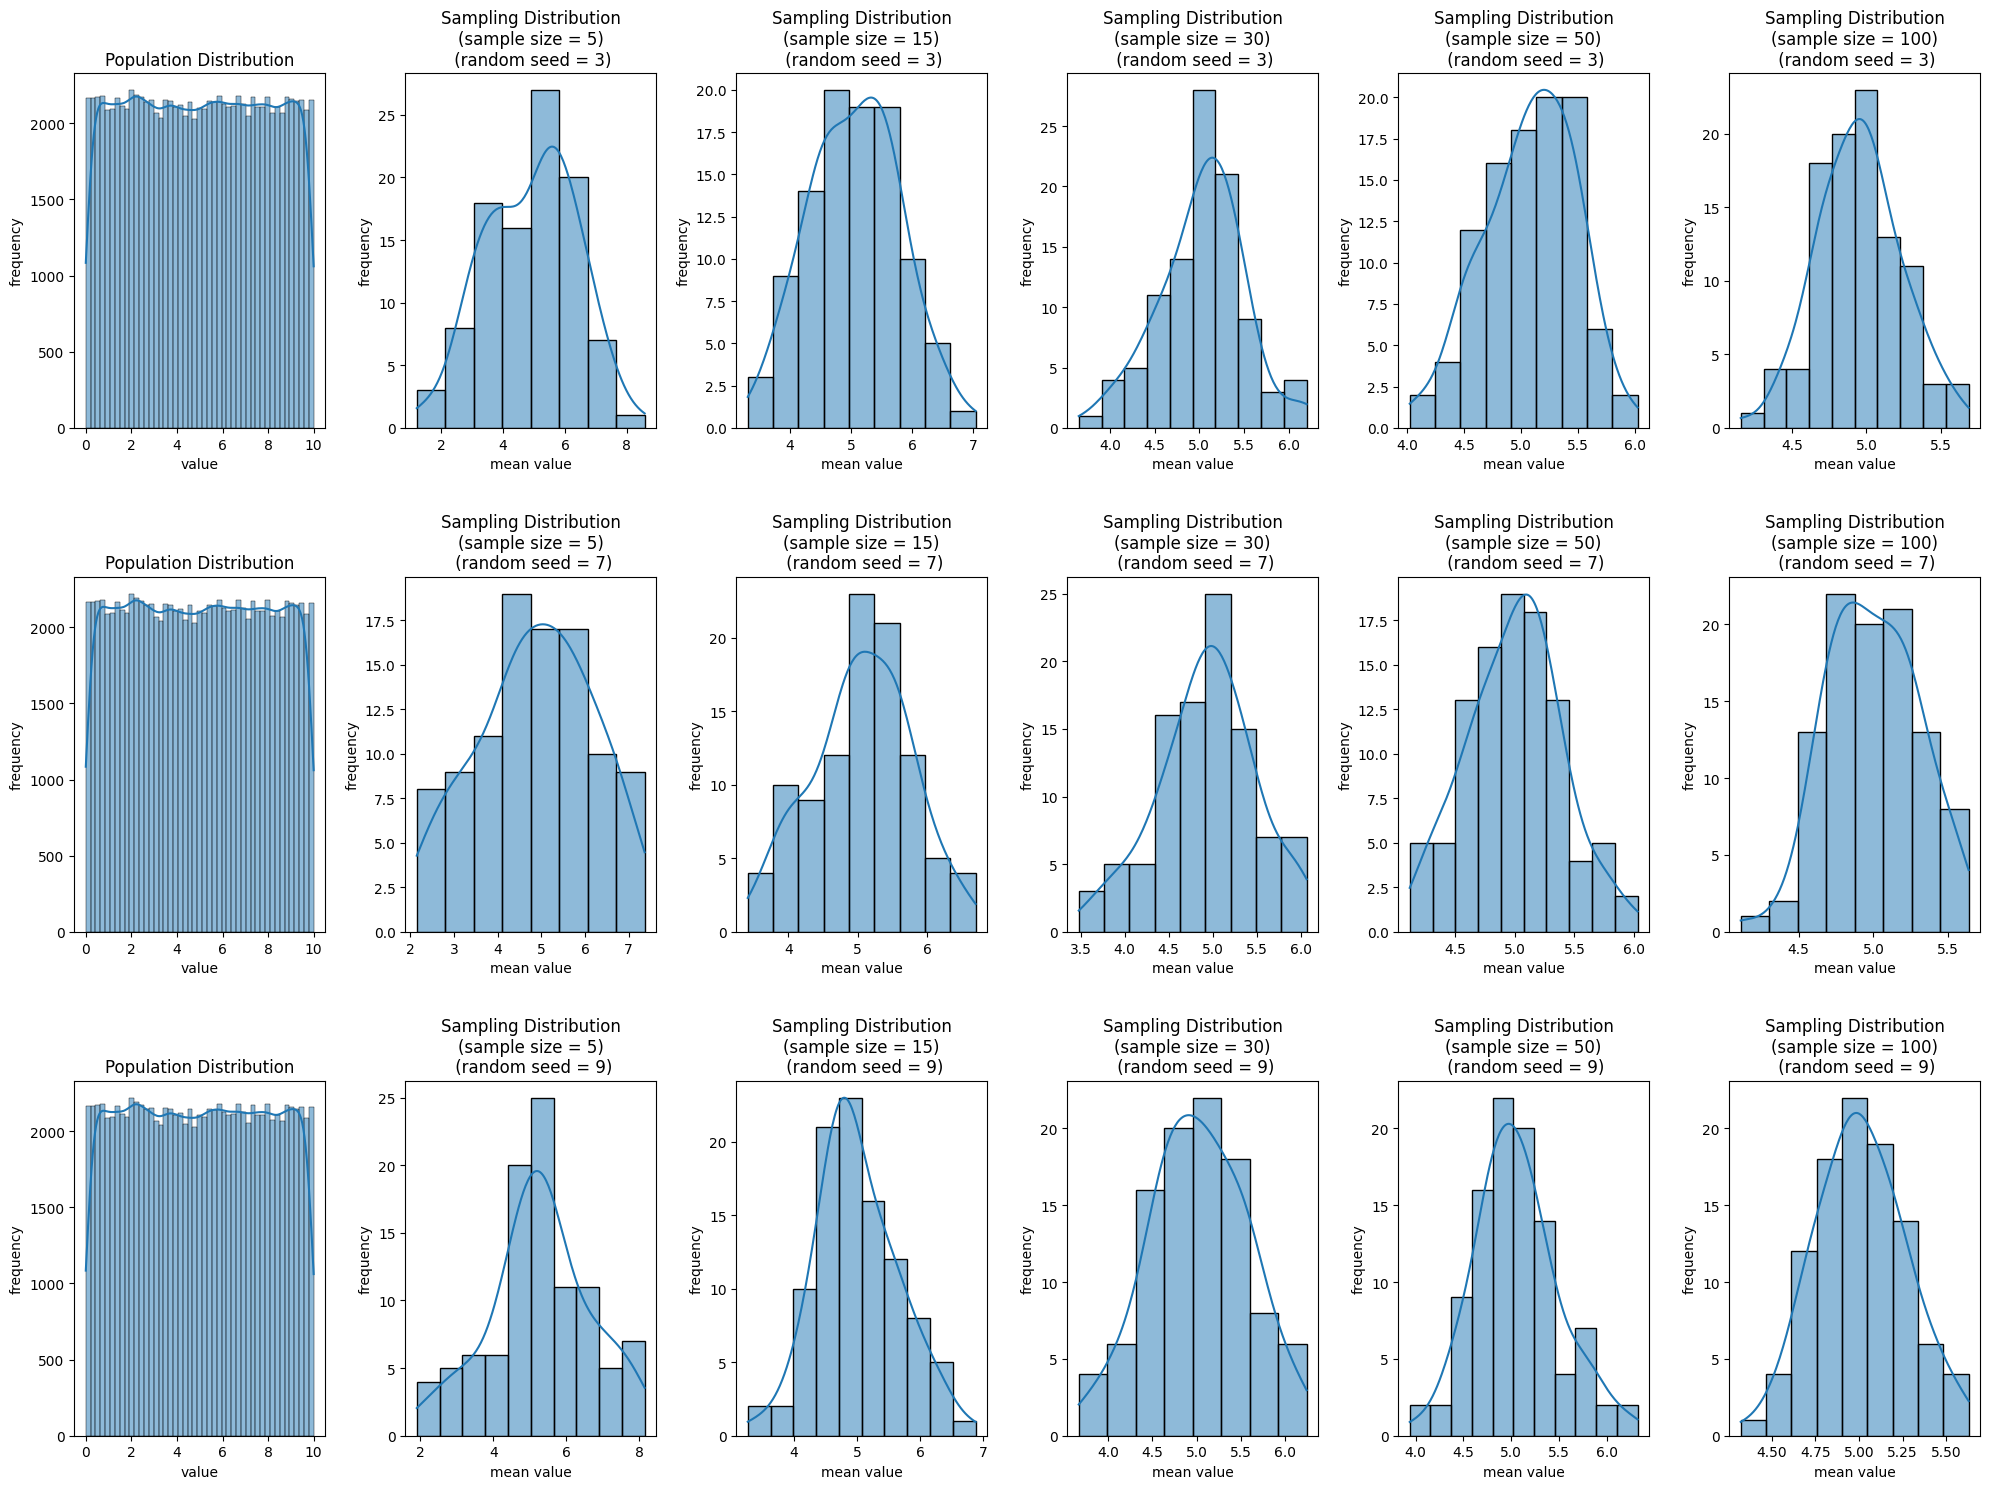

In [16]:
# uniform distributed population
np.random.seed(1)
uniform_pop = stats.uniform.rvs(0, 10, size=100000)
sample_distributions(uniform_pop)

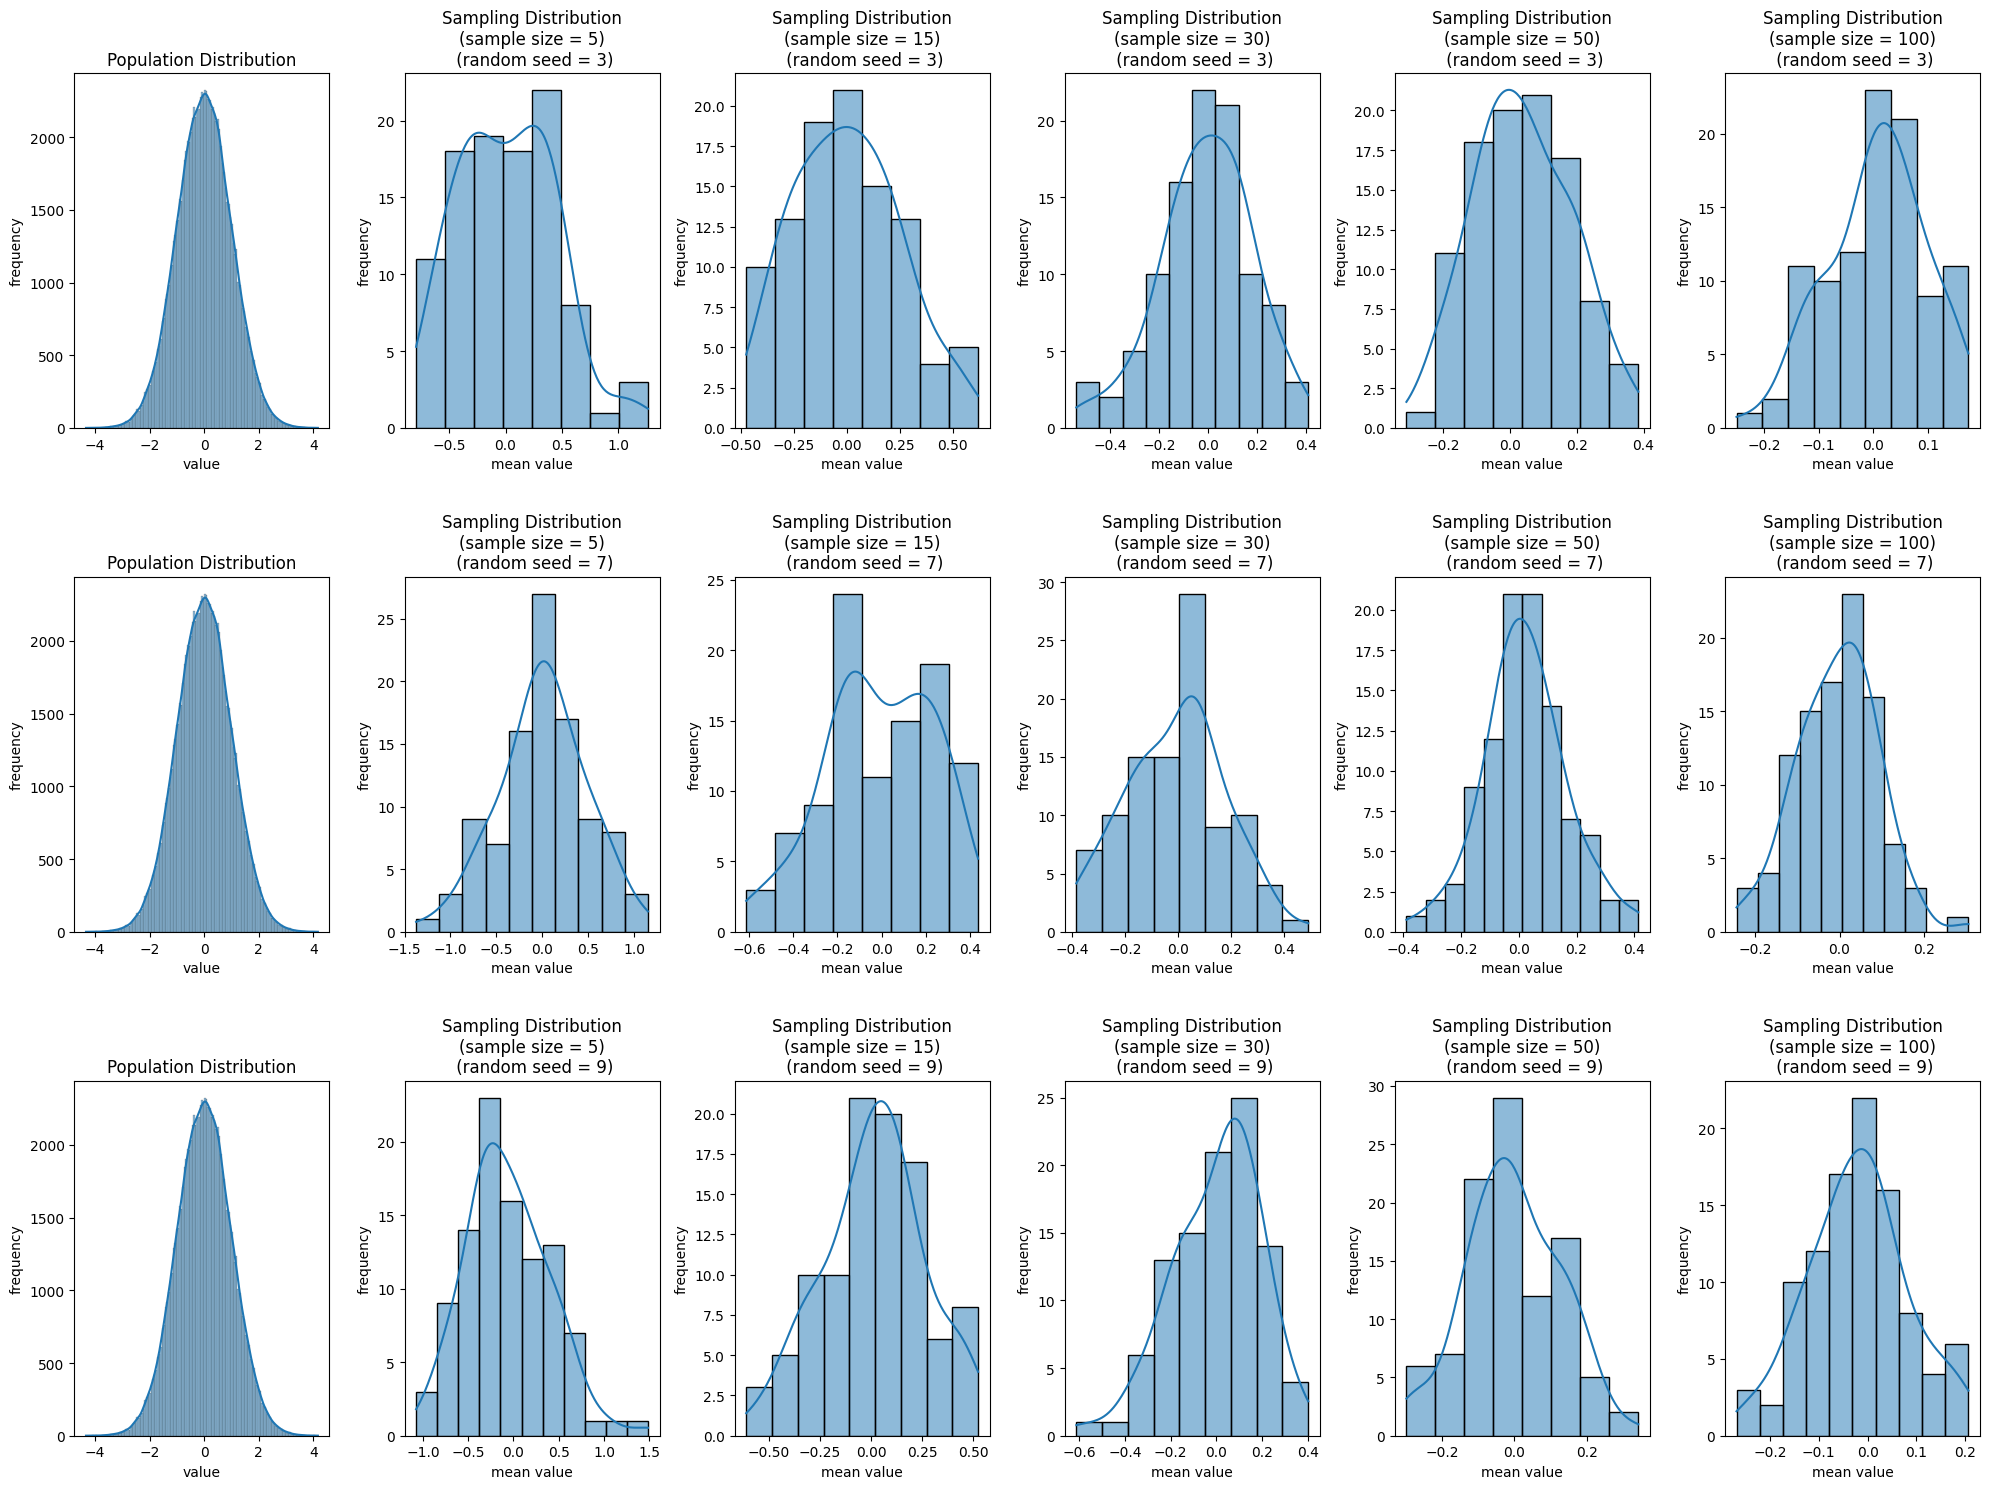

In [17]:
# normal distributed population
np.random.seed(1)
normal_pop = stats.norm.rvs(0, 1, size=100000)
sample_distributions(normal_pop)

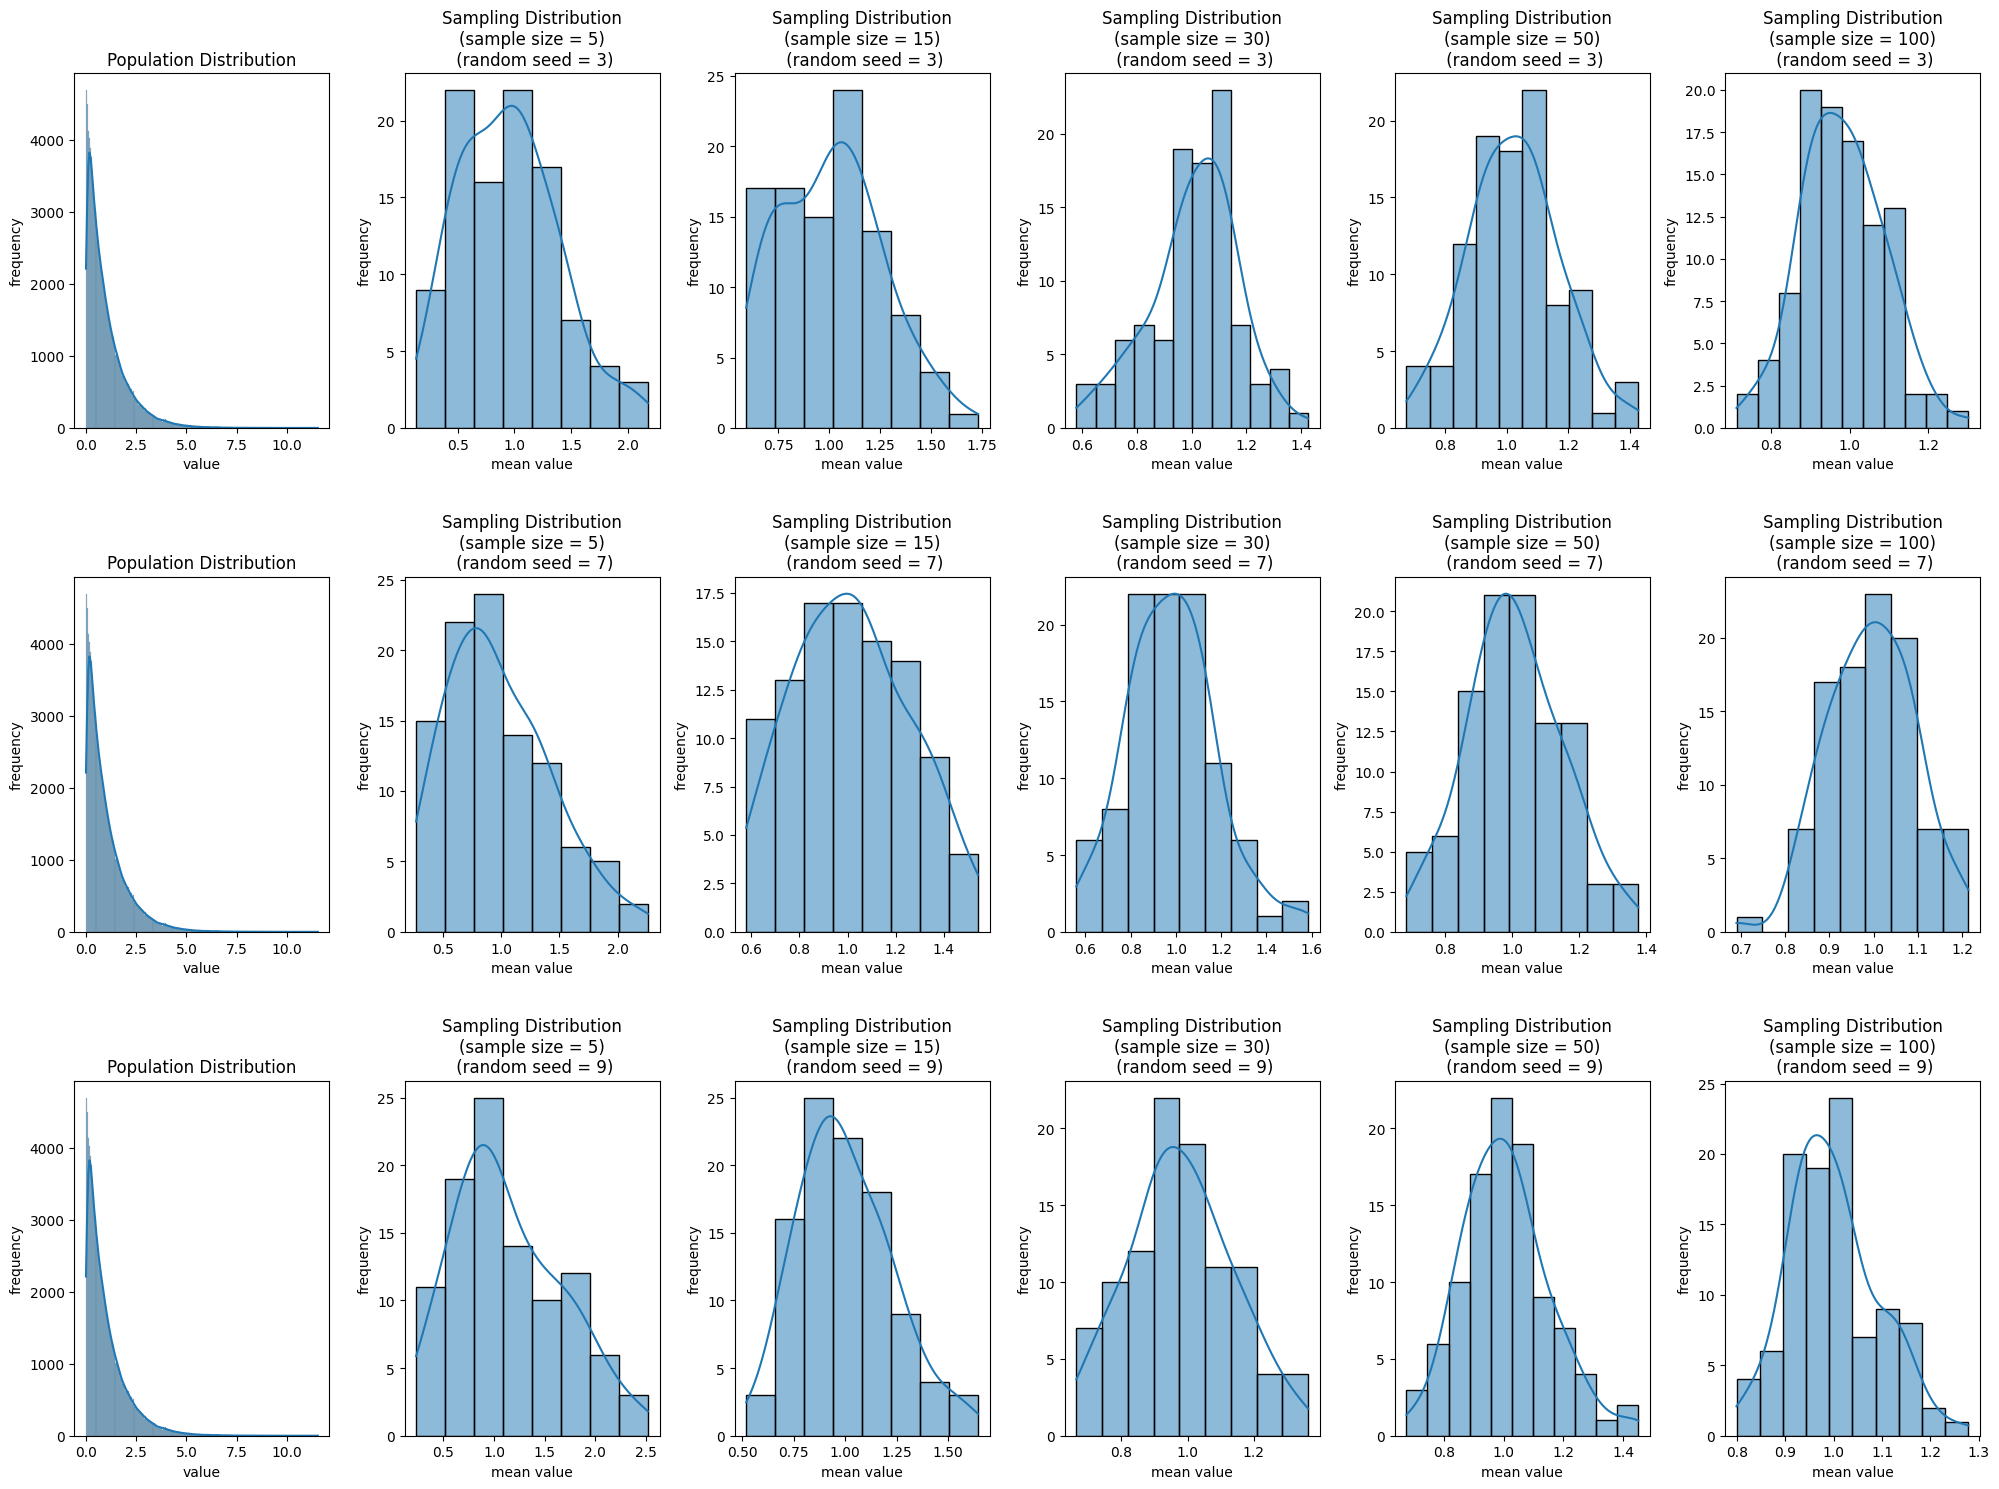

In [18]:
# exponential distributed population
np.random.seed(1)
exponential_pop = stats.expon.rvs(size=100000)
sample_distributions(exponential_pop)

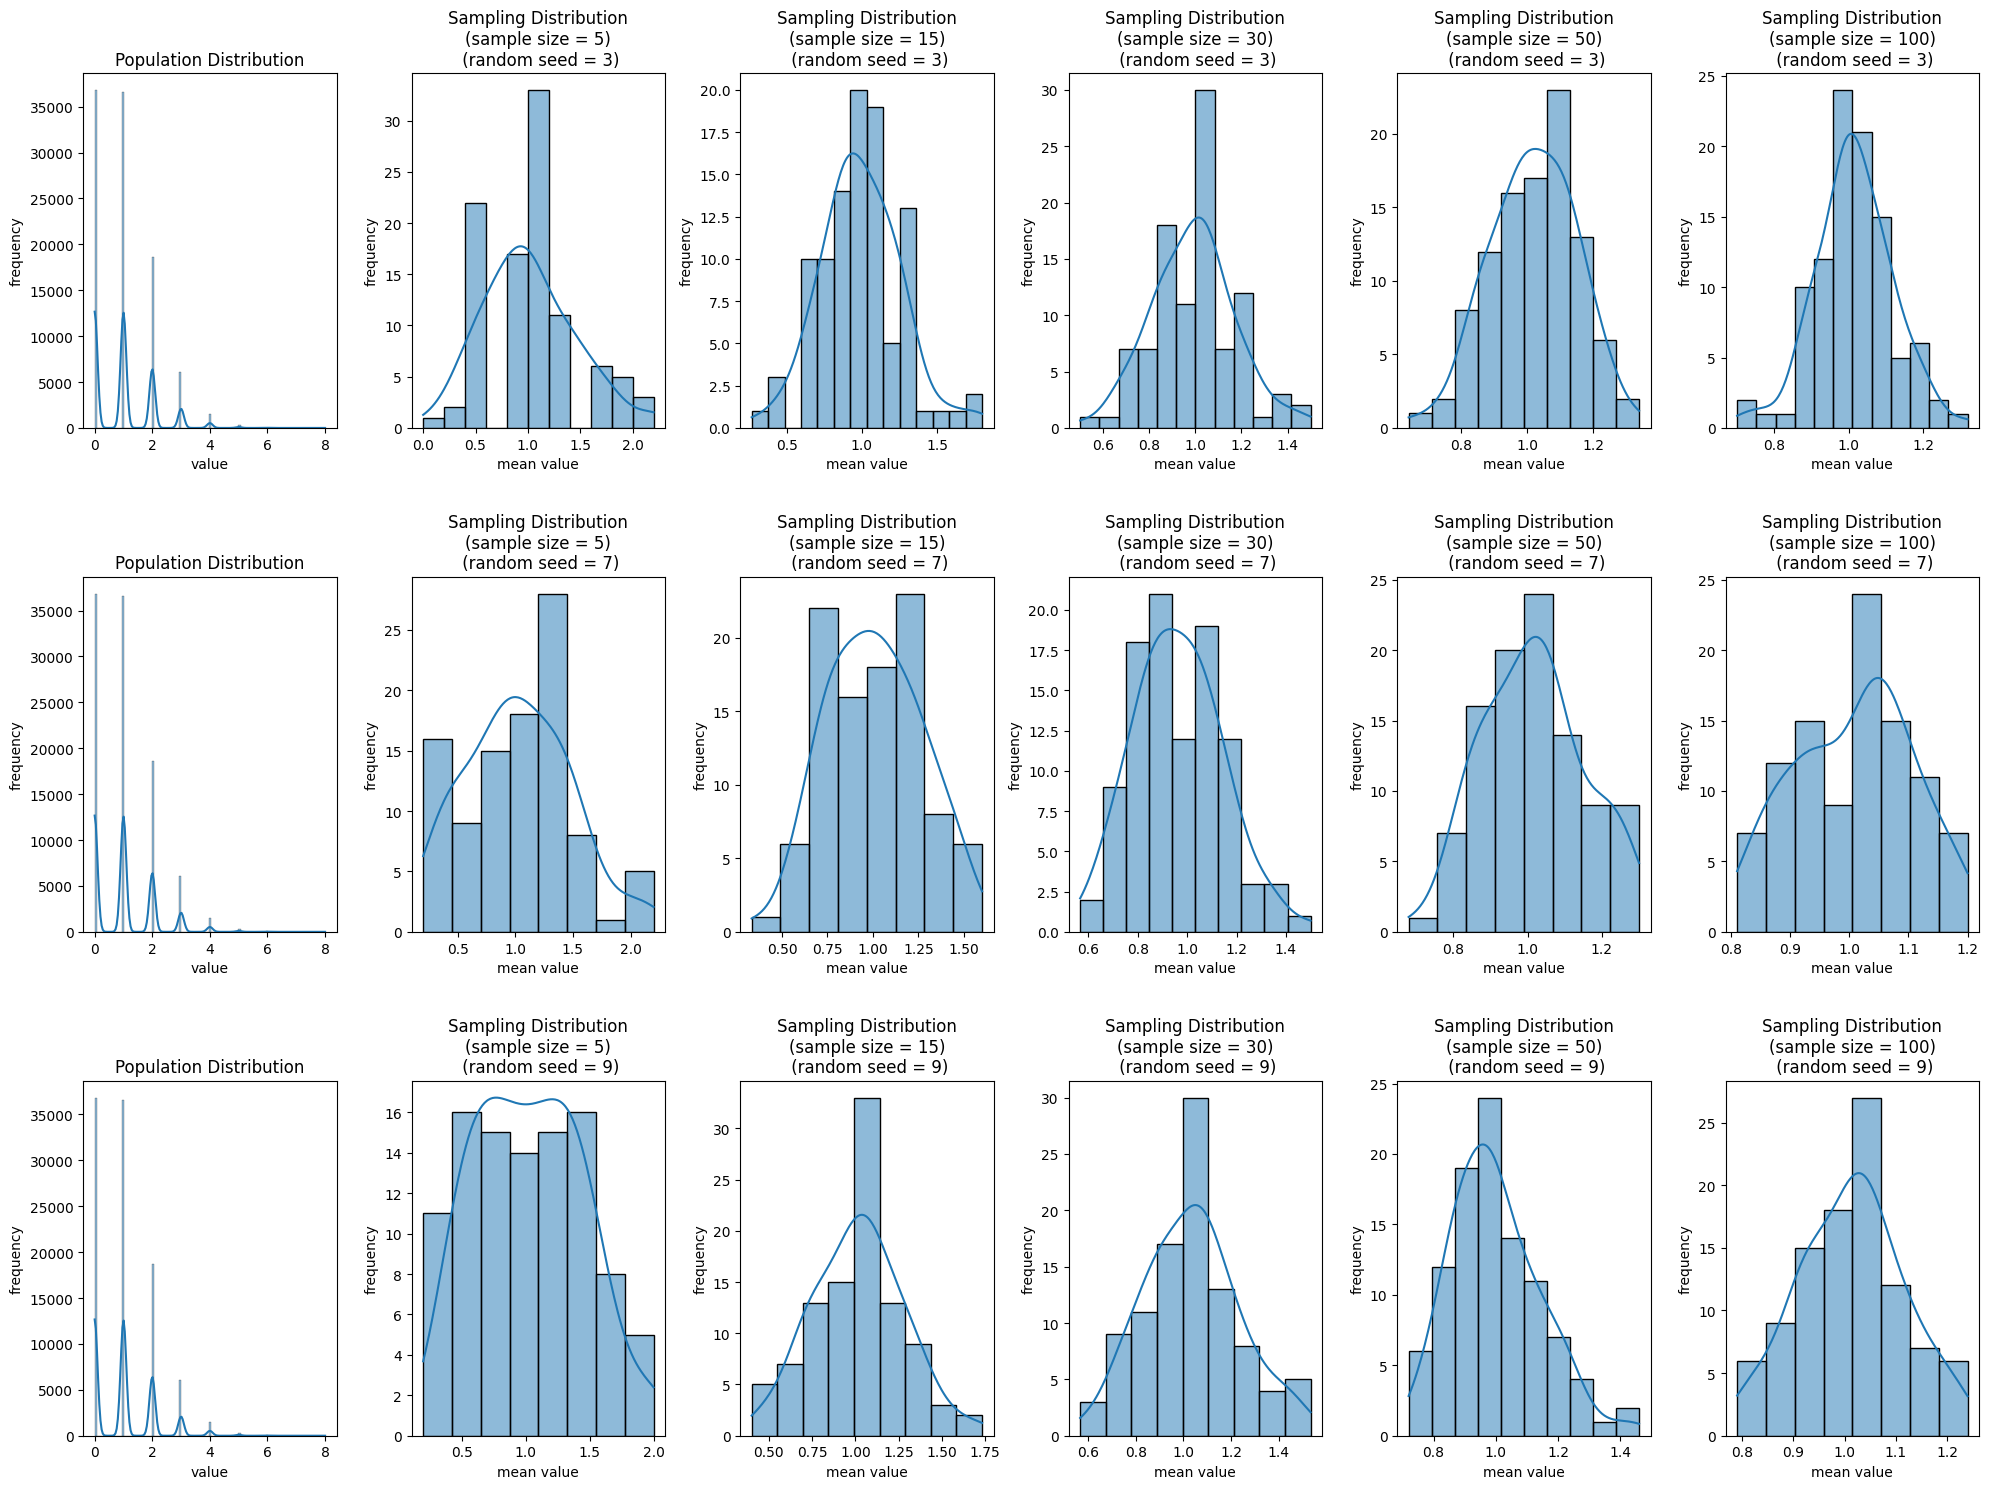

In [19]:
# poisson distributed population
np.random.seed(1)
poisson_pop = stats.poisson.rvs(1, size=100000)
sample_distributions(poisson_pop)

In [20]:
# # binomial distributed population
# np.random.seed(1)
# binomial_pop = stats.binom.rvs(10, 0.5, size=100000)
# sample_distributions(binomial_pop)

In [21]:
# # chi-squared distributed population
# np.random.seed(1)
# chi_squared_pop = stats.chi2.rvs(5, size=100000)
# sample_distributions(chi_squared_pop)

In [22]:
# # t-distributed population
# np.random.seed(1)
# t_pop = stats.t.rvs(5, size=100000)
# sample_distributions(t_pop)

In [23]:
# # f-distributed population
# np.random.seed(1)
# f_pop = stats.f.rvs(5, 5, size=100000)
# sample_distributions(f_pop)

# Estimation & Confidence Interval

estimatino is to make inference about a population parameter based on sample statistic

### point estimation
single point estimatino of the populatin parameter
- doesn't take the sampling distributin into accout

### interval estimation (confidence interval)
a range of values within which the population parameter is likely to fall
- point estimation +- margin of error
- adds a level of confidence to the point estimation (e.g. 95% confident that the population parameter falls within the interval)


### example case - population std dev is known
the caffeine content (in mg) was examined for a random sample of 50 cups of black coffee dispensed by a new coffee machine. the mean of the sample is found to be 110 mg. it is known that the standard deviation from all the machines of that manufacturer is 7 mg. construct a 95% confidence interval for the mean caffeine content of the coffee dispensed by the new machine.

In [24]:
# if the population standard deviation is known, use the z-distribution (z-score)
sample_mean = 110
population_std = 7
sample_size = 50
sample_std = population_std / np.sqrt(sample_size)

# using interval
z_min, z_max = stats.norm.interval(
    confidence=0.95, 
    loc=sample_mean, 
    scale=sample_std
)

# using z-score
# calculate the z-score using ppf if not already known (e.g. via lookup table or memorization)
confidence = 0.95
outer_percentile = 1 - confidence # 5% on the outside
outer_left_percentile = outer_percentile / 2 # half on left side, half on right side
neg_z = stats.norm.ppf(outer_left_percentile) # get the point at which the cdf is equal to the outer left of the 95% confidence interval
z = np.abs(neg_z) # flip the negative z-score to get the 95% confidence z-score
print(f'z: {z.round(2)}') # z = 1.96 for a 95% confidence interval

# calculate the confidence interval using the z-score
z_min2 = sample_mean - z * sample_std
z_max2 = sample_mean + z * sample_std

print(f'interval: 95% confidence interval for a mean of {sample_mean} and sigma of {population_std} = ({z_min.round(2)}, {z_max.round(2)})')
print(f'ppf:      95% confidence interval for a mean of {sample_mean} and sigma of {population_std} = ({z_min2.round(2)}, {z_max2.round(2)})')

z: 1.96
interval: 95% confidence interval for a mean of 110 and sigma of 7 = (108.06, 111.94)
ppf:      95% confidence interval for a mean of 110 and sigma of 7 = (108.06, 111.94)


### example case - population std dev is unknown (t-distribution)
population std dev is unknown, so we use the sample std dev to estimate the population std dev using the t-distribution with n-1 degrees of freedom
- the t-distribution is similar to the normal distribution, but with heavier tails
- as the sample size increases, the t-distribution approaches the normal distribution

#### t-distribution v.s. normal distribution

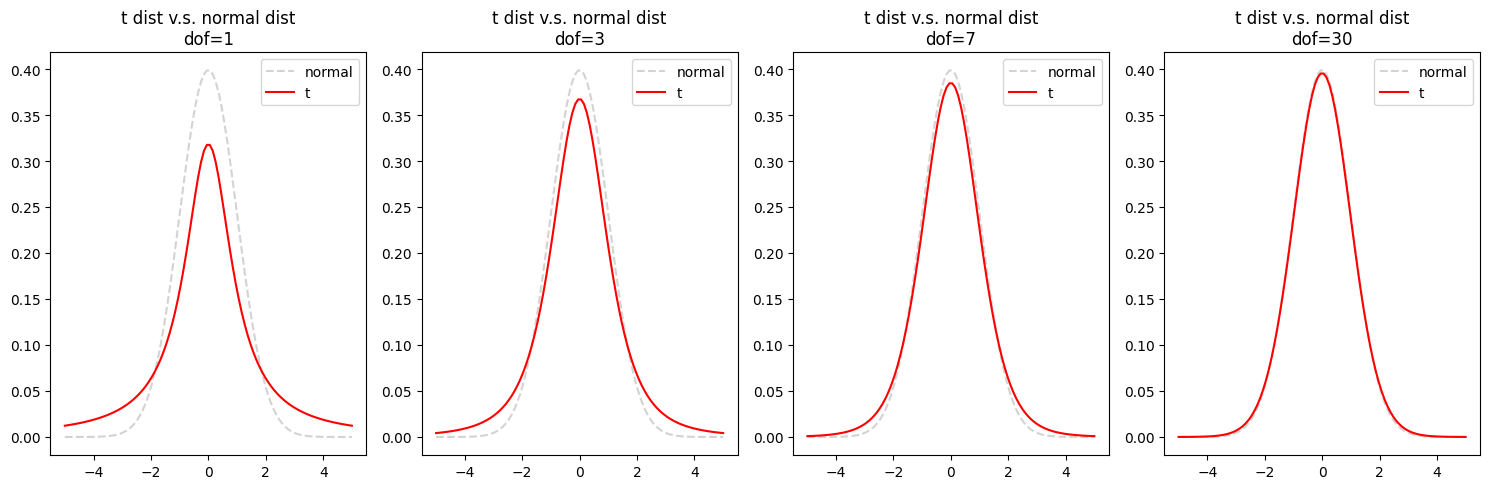

In [25]:
def t_vs_norm(dof, ax, title):
    x = np.linspace(-5, 5, 100)
    y_norm = stats.norm.pdf(x, 0, 1)
    y_t = stats.t.pdf(x, dof)
    ax.plot(x, y_norm, label='normal', color='lightgray', linestyle='--')
    ax.plot(x, y_t, label='t', color='r')
    ax.legend()
    ax.set_title(title)

dofs = [1, 3, 7, 30]
fig, ax = plt.subplots(1, len(dofs), figsize=(15, 5))
for i, dof in enumerate(dofs):
    t_vs_norm(dof, ax[i], f't dist v.s. normal dist\ndof={dof}')

plt.tight_layout()
plt.show()

In [26]:
# t-distribution example
sample_mean = 110
sample_std = 7
sample_size = 50
dof = sample_size - 1
confidence = 0.95
std_err = sample_std / np.sqrt(sample_size) # standard error of the mean
"""
The SEM quantifies how much the sample mean is expected to vary from the true population mean.
It is derived from the population standard deviation, but since we're dealing with a sample, it needs to be adjusted for the sample size.
The reason for dividing by sqrt(n) is due to the Central Limit Theorem; "as n increases, the distribution of the sample means gets tighter around the population mean."
"""

# using interval
t_min, t_max = stats.t.interval(
    confidence=confidence, 
    df=dof, 
    loc=sample_mean, 
    scale=std_err
)

# using t-score
# calculate the t-score using ppf if not already known (e.g. via lookup table or memorization)
outer_percentile = 1 - confidence # 5% on the outside
outer_left_percentile = outer_percentile / 2 # half on left side, half on right side
neg_t = stats.t.ppf(outer_left_percentile, dof) # get the point at which the cdf is equal to the outer left of the 95% confidence interval
t = np.abs(neg_t) # flip the negative t-score to get the 95% confidence t-score
print(f't: {t.round(2)}')

# calculate the confidence interval using the t-score
t_min2 = sample_mean - t * std_err
t_max2 = sample_mean + t * std_err
print(f'interval: 95% confidence interval for a mean of {sample_mean} and sigma of {population_std} = ({t_min.round(2)}, {t_max.round(2)})')
print(f'interval: 95% confidence interval for a mean of {sample_mean} and sigma of {population_std} = ({t_min2.round(2)}, {t_max2.round(2)})')

t: 2.01
interval: 95% confidence interval for a mean of 110 and sigma of 7 = (108.01, 111.99)
interval: 95% confidence interval for a mean of 110 and sigma of 7 = (108.01, 111.99)


In [27]:
print(f'difference between t-score and z-score: ({(t_min - z_min).round(2)}, {(t_max - z_max).round(2)})')

difference between t-score and z-score: (-0.05, 0.05)


# hypothesis testing

Basically we have a distribution of the current state, and a claim about an alternative state.

Plug a sample from the alternative state into a cdf of the current state and calculate the probabilty of getting that sample. 

If the probability is low, we reject the current state
- current state = null hypothesis
- alternative state = alternative hypothesis

#### for example:
1. given a coin, status quo is that the coin is fair (null hypothesis)

2. sampling, we flip the coin and get heads 60 out of 100 samples

3. we claim that the coin is biased (alternative hypothesis)

4. the probability of getting >= 60 heads in 100 coin flips is 3%. 

5. This is low enough that we can reject the null hypothesis that the coin is fair. 
    - i.e. we can accept the alternative hypothesis that the coin is biased

In [28]:
# calculate the probability of flipping >= 60 heads out of 100 coin flips
n = 100
p = 0.5
k = 60
# k-1 because this is a discrete distribution, and we want to eventually calculate P(x >= 60)
# if this were a continuous distribution, we would just plug in k, because p(x = k) is so small, it's effectively 0
p_less_than_k = stats.binom.cdf(k-1, n, p) 
p_greater_than_or_equal_to_k = 1 - p_less_than_k
print(f'probability of flipping {k}+ heads out of {n} coin flips: {p_greater_than_or_equal_to_k.round(2)}')

probability of flipping 60+ heads out of 100 coin flips: 0.03


## hypothesis error types
in many cases, we typically want to minimize false negatives, even if it means increasing false positives.
- e.g. in medical testing, we want to minimize the number of sick people who are told they are healthy, even if it means increasing the number of healthy people who are told they are sick

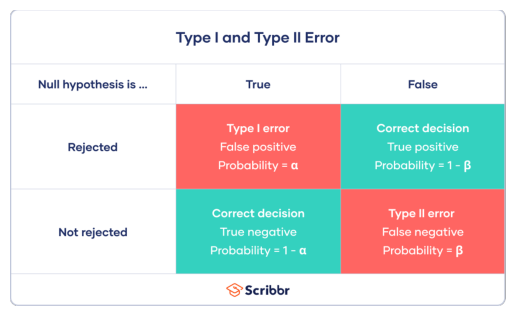

In [29]:
print_image('assets/type_error_graph.png')